<a href="https://colab.research.google.com/github/gdhameja1/ML/blob/main/Classification_Models_Exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classification Models: From Binary Diagnosis to Multiclass Prediction

---

> ### 📋 Practice Exercise. Not Graded.
> This is a **practice assignment** for self-assessment. The marks shown throughout are **indicative only**. They tell you where to spend your effort and where you might need more practice. **None of these marks count towards your final grade.**
>
> Attempt every section. Compare your results. Revisit what trips you up.

---

## What You Will Build

Two classifiers, two datasets, one progression from simple to complex.

| Part | Dataset | Task | Primary Metric |
|------|---------|------|----------------|
| **Part 1** | Breast Cancer (sklearn) | Binary: Malignant vs Benign | Recall (Sensitivity) |
| **Part 2** | Wine (sklearn) | Multiclass: 3 wine cultivars | Macro-averaged F1-Score |

**Indicative Marks: 100** (Part 1: 55 | Part 2: 45)

### Before You Start
- Complete all cells marked with `# TODO`.
- Markdown cells marked **[Your Answer]** need written responses. Don't skip them.
- Run `Runtime > Restart and run all` before reviewing. The notebook should execute top to bottom without errors.
- Use `random_state=42` wherever a function accepts it. This keeps your results reproducible.


---
# PART 1: Binary Classification, Breast Cancer Prediction

## Context

Early detection of malignant tumours saves lives. In this part, you will build classifiers that predict whether a breast tumour is **malignant** or **benign** based on features computed from cell nuclei images.

**Why Recall matters here:** A false negative means telling a patient their tumour is benign when it is actually malignant. That is a missed cancer diagnosis. A false positive means an unnecessary follow-up test. Annoying, but survivable. The asymmetry is stark: we prioritise **recall for the malignant class** above everything else.

> **Clinical Constraint:** We want recall ≥ 0.95 for malignant cases, while keeping precision ≥ 0.60 (i.e., not flooding clinics with false alarms).


## Stage 1: Data and Package Loading

<font color="red">**[3 marks]**</font>

Load the Breast Cancer Wisconsin dataset from `sklearn.datasets`.

**What to do:**
- The libraries below are pre-imported. Review them, add anything else you need.
- Load the dataset using `load_breast_cancer()`
- Convert it to a DataFrame with proper column names
- Separate features (`X`) and target (`y`)

> **Watch out:** In the raw dataset, `0 = malignant` and `1 = benign`. Since `recall_score` defaults to `pos_label=1`, we need malignant to be 1. **Remap the target** with `y = 1 - data.target`.


In [186]:
# Pre-imported libraries. Review these, add what you need below.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.metrics import (accuracy_score, recall_score, precision_score, f1_score,
                             confusion_matrix, classification_report, roc_curve, roc_auc_score,
                             precision_recall_curve)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

import warnings
warnings.filterwarnings('ignore')


In [187]:
# Load the breast cancer dataset and convert to DataFrame
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target




In [188]:
# Separate features and target, remap so malignant = 1
X = df.drop('target', axis=1)
y = 1 - df['target']

print("Features shape:", X.shape)
print("Target distribution:")
print(y.value_counts())


Features shape: (569, 30)
Target distribution:
target
0    357
1    212
Name: count, dtype: int64


## Stage 2: Data Understanding

<font color="red">**[8 marks]**</font>

Before building any model, understand the data.


### 2.1 Basic Inspection <font color="red">[2 marks]</font>

Display the first few rows, check the shape, data types, and confirm there are no missing values.


In [189]:
# Display first 5 rows
df.head()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [190]:
# Check shape, data types, and missing values
# Check shape
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

# Check data types
print("\nData types:")
print(X.dtypes)

# Check missing values
print("\nMissing values:")
print(X.isnull().sum())

print("\nTotal missing values:", X.isnull().sum().sum())


Shape of X: (569, 30)
Shape of y: (569,)

Data types:
mean radius                float64
mean texture               float64
mean perimeter             float64
mean area                  float64
mean smoothness            float64
mean compactness           float64
mean concavity             float64
mean concave points        float64
mean symmetry              float64
mean fractal dimension     float64
radius error               float64
texture error              float64
perimeter error            float64
area error                 float64
smoothness error           float64
compactness error          float64
concavity error            float64
concave points error       float64
symmetry error             float64
fractal dimension error    float64
worst radius               float64
worst texture              float64
worst perimeter            float64
worst area                 float64
worst smoothness           float64
worst compactness          float64
worst concavity            float64
w

### 2.2 Summary Statistics <font color="red">[2 marks]</font>

Generate descriptive statistics. Pay attention to the **scale differences** across features. Some features range in the hundreds, others below 1. This matters for your preprocessing choices.


In [191]:
# Summary statistics
# Note the scale differences: mean radius is ~14, mean area is ~654, mean fractal dimension is ~0.06
X.describe()

# Check selected feature means
print("Mean radius:", X['mean radius'].mean())
print("Mean area:", X['mean area'].mean())
print("Mean fractal dimension:", X['mean fractal dimension'].mean())


Mean radius: 14.127291739894552
Mean area: 654.8891036906855
Mean fractal dimension: 0.06279760984182776


### 2.3 Class Distribution <font color="red">[2 marks]</font>

How many malignant vs benign cases are there? Visualise this with a bar plot.


Class distribution:
target
Benign       357
Malignant    212
Name: count, dtype: int64


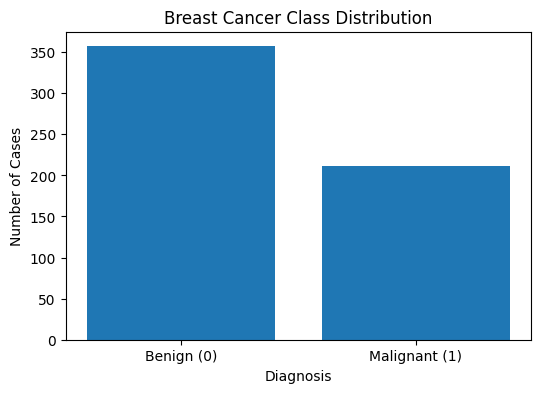

In [192]:
# Class distribution after remapping
print("Class distribution:")
print(y.value_counts().rename({0: "Benign", 1: "Malignant"}))
# Class distribution
class_counts = y.value_counts().sort_index()

# Bar plot
plt.figure(figsize=(6, 4))
plt.bar(['Benign (0)', 'Malignant (1)'], class_counts.values)

plt.xlabel('Diagnosis')
plt.ylabel('Number of Cases')
plt.title('Breast Cancer Class Distribution')
plt.show()


### 2.4 Feature Distributions <font color="red">[2 marks]</font>

Pick 4-6 features and plot their distributions using histograms or boxplots. Look for skewness, outliers, and whether the two classes separate visually on any feature.


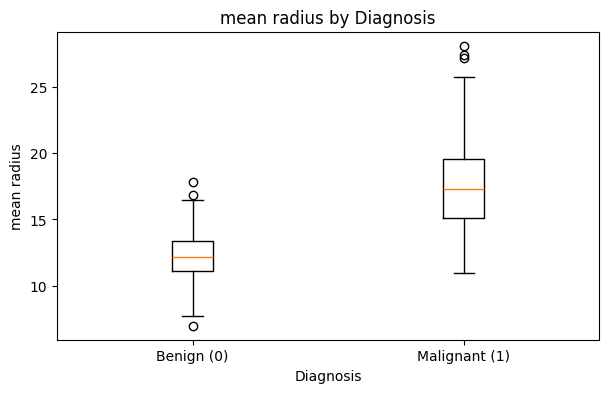

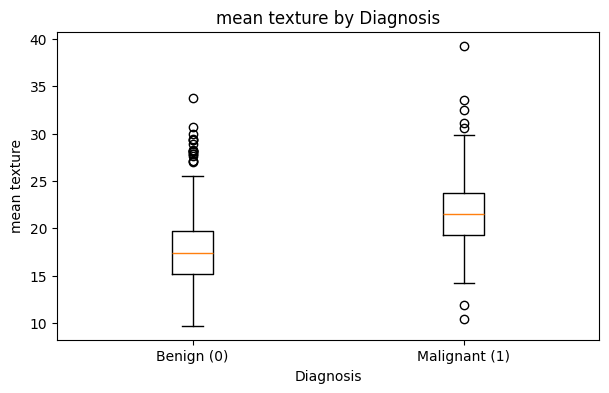

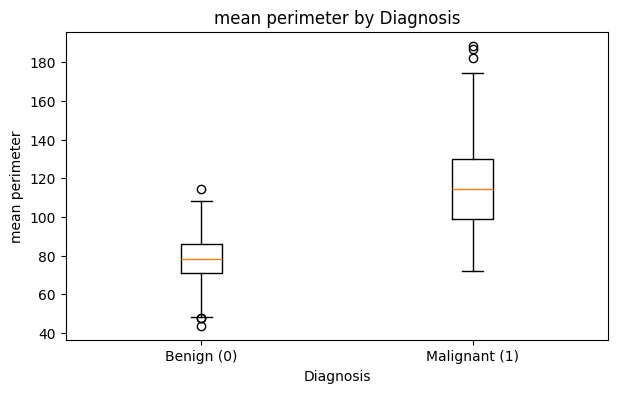

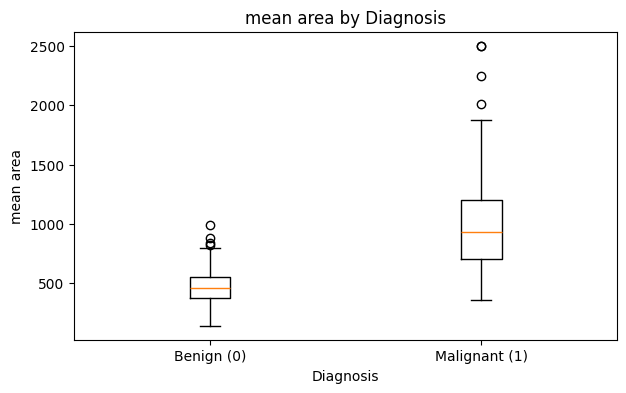

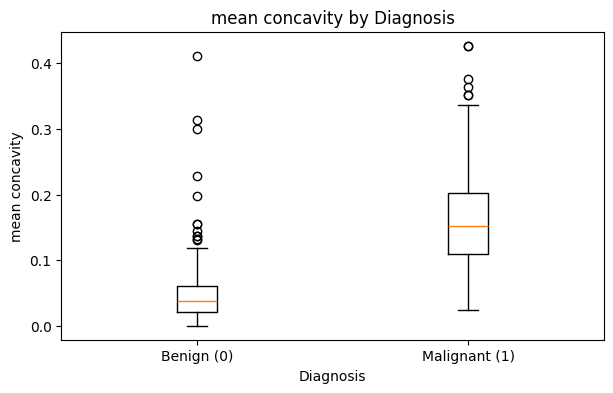

In [193]:
# Feature distributions for 6 selected features, coloured by class
features = [
    'mean radius',
    'mean texture',
    'mean perimeter',
    'mean area',
    'mean concavity'
]

for feature in features:
    plt.figure(figsize=(7, 4))

    plt.boxplot(
        [
            X.loc[y == 0, feature],
            X.loc[y == 1, feature]
        ],
        labels=['Benign (0)', 'Malignant (1)']
    )

    plt.xlabel('Diagnosis')
    plt.ylabel(feature)
    plt.title(f'{feature} by Diagnosis')
    plt.show()


### ✍️ Interpretation Checkpoint

**[Your Answer]:** Answer these questions in 2-3 sentences each:
1. Is the dataset balanced? How might imbalance affect model training?
2. Do the features have similar scales? What does this mean for models like KNN and SVM?
3. Why is recall a better primary metric than accuracy for this problem?
4. Why must we fit the scaler on training data only and not on the full dataset? What information from the test set would leak into training if we did?




1. No, the dataset is moderately imbalanced, with approximately 63% benign and 37% malignant cases. This can cause a model to favor the majority class (benign) and potentially miss malignant cases, making accuracy misleading.

2. No, the features have very different scales; for example, mean radius is around 14, mean area is around 654, while mean fractal dimension is around 0.06. Since KNN and SVM are sensitive to feature magnitudes, larger-scale features can disproportionately influence the model, so standardization is important.

3. Recall is more important because it measures the proportion of actual malignant cases correctly identified. A false negative—predicting a malignant tumor as benign—can have serious consequences, so we want to minimize missed cancer cases even if this reduces overall accuracy.

4. The scaler must be fitted only on training data to prevent data leakage from the test set into the model-building process. If we fit it on the full dataset, the test set's statistics such as mean and standard deviation would influence the scaling parameters, giving the model information about unseen data and producing an overly optimistic evaluation.


## Stage 3: Data Preprocessing and Preparation

<font color="red">**[7 marks]**</font>


### 3.1 Missing Value Audit <font color="red">[1 mark]</font>

Confirm no missing values exist. If any do, handle them with median imputation.


In [194]:
# Missing value audit

# Check for missing values
print("Missing values before imputation:")
print(X.isnull().sum())

# Handle missing values using median imputation
X = X.fillna(X.median())

# Confirm no missing values remain
print("\nTotal missing values after imputation:", X.isnull().sum().sum())


Missing values before imputation:
mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
dtype: int64

Total missing values after imputation: 0


### 3.2 Train-Test Split <font color="red">[2 marks]</font>

Split into 70% training and 30% test using **stratified sampling** to preserve the class ratio to mitigate any slight class imbalance. Use `random_state=42`.


In [195]:
# Stratified train-test split
# Split into 70% training and 30% test using stratified sampling
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

# Check the shapes
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

# Check class proportions
print("\nTraining class distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest class distribution:")
print(y_test.value_counts(normalize=True))


X_train: (398, 30)
X_test: (171, 30)
y_train: (398,)
y_test: (171,)

Training class distribution:
target
0    0.628141
1    0.371859
Name: proportion, dtype: float64

Test class distribution:
target
0    0.625731
1    0.374269
Name: proportion, dtype: float64


### 3.3 Feature Scaling <font color="red">[2 marks]</font>

Apply `StandardScaler`. **Fit the scaler on training data only**, then transform both train and test sets. If you fit on the full dataset, the scaler learns the mean and standard deviation of the test data, which inflates your results. That is data leakage.

> **Note:** Decision Trees split on thresholds and don't need scaling. But for consistency here, we scale for all models.


In [196]:
# Feature scaling: fit on train only, transform both

# Create the scaler
scaler = StandardScaler()

# Fit ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using the scaler fitted on training data
X_test_scaled = scaler.transform(X_test)


### 3.4 Confirm Prepared Data <font color="red">[2 marks]</font>

Print shapes of your final training and test sets. Verify the class distribution is preserved in both.


In [197]:
# Confirm prepared data

# Check the shapes
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

print("Training means:")
print(X_train_scaled.mean(axis=0))

print("\nTraining standard deviations:")
print(X_train_scaled.std(axis=0))


X_train_scaled shape: (398, 30)
X_test_scaled shape: (171, 30)
Training means:
[ 4.46320814e-17 -4.40741804e-16  7.93335247e-16  5.35584977e-17
 -1.64022899e-16 -9.14957669e-17 -1.27201432e-16 -6.69481221e-18
  1.54427002e-15  1.37689971e-15  0.00000000e+00 -2.23160407e-16
  4.46320814e-18 -1.78528326e-17 -2.85645321e-16 -1.38359452e-16
  6.24849139e-17  2.66676686e-16 -3.21350986e-16 -1.78528326e-17
 -1.76296721e-16 -3.92762316e-16  2.58866072e-16 -2.68908290e-16
 -2.00844366e-17  1.76296721e-16 -1.17159214e-16 -1.29433036e-16
 -3.43667027e-16  1.20506620e-16]

Training standard deviations:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1.]


## Helper: Evaluation Function

You will evaluate many models. Rather than copy-pasting the same five lines every time, define a reusable function. Call it throughout Stages 4-6.


In [198]:
# Helper function. Use this to evaluate all models consistently.

def evaluate_model(model, X_test, y_test):
    """
    Evaluate a classification model using key performance metrics.
    """

    # Make predictions
    y_pred = model.predict(X_test)

    # Probability predictions for ROC-AUC
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.decision_function(X_test)

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)

    #Multi class
    precision = precision_score(
        y_test,
        y_pred,
        average='macro'
    )

    recall = recall_score(
        y_test,
        y_pred,
        average='macro'
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average='macro'
    )

    ###roc_auc = roc_auc_score(
    ##    y_test,
     ##   y_prob,
     ##   multi_class='ovr',
     ##   average='macro'
   ## )


    # Display results
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Macro : {f1:.4f}")
   # print(f"ROC-AUC  : {roc_auc:.4f}")

    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        #"ROC-AUC": roc_auc
    }


## How GridSearchCV Works

If you haven't used `GridSearchCV` before, read this before moving on.

`GridSearchCV` automates hyperparameter tuning. You give it a set of parameter values to try, and it trains a model for every combination, scores each one using cross-validation, and tells you which combination won.

You can refer to the [documentation](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html)

Here is the pattern you will repeat for every model below:

```python
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# 1. Define what parameter values to try
param_grid = {'C': [0.1, 1, 10]}

# 2. Set up GridSearchCV
grid = GridSearchCV(
    estimator=LogisticRegression(random_state=42, max_iter=10000),
    param_grid=param_grid,
    scoring='recall',   # what metric to optimise
    cv=5,               # 5-fold cross-validation on training data
    n_jobs=-1            # use all CPU cores
)

# 3. Fit on training data
grid.fit(X_train_scaled, y_train)

# 4. Check results
print("Best parameters:", grid.best_params_)
print("Best CV recall:", grid.best_score_)
best_model = grid.best_estimator_

# 5. Predict on test set
y_pred = best_model.predict(X_test_scaled)
```

Every model below follows the same five steps. The only things that change are the estimator and the parameter grid.


## Stage 4: Model Training, Hyperparameter Tuning, and Evaluation

<font color="red">**[23 marks]**</font>

Train **four classifiers**, tune them, evaluate each one.

For each model:
1. Define the parameter grid
2. Run `GridSearchCV` with `scoring='recall'`, `cv=5`
3. Print the best parameters
4. Predict on the test set using the best estimator
5. Evaluate using `evaluate_model()`

> We use `scoring='recall'` because our goal is to catch malignant cases. Accuracy is misleading when classes are imbalanced.


### 4.1 Logistic Regression (Baseline) <font color="red">[5 marks]</font>

Logistic Regression with `class_weight='balanced'` to handle class imbalance.

**Hyperparameters to tune:**
- `C`: Regularisation strength. Try `[0.01, 0.1, 1, 10, 100]`
- Set `max_iter=10000` and `random_state=42`


In [199]:
# Logistic Regression with GridSearchCV

# Define Logistic Regression
log_reg = LogisticRegression(
    class_weight='balanced',
    max_iter=10000,
    random_state=42
)

# Define parameter grid
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100]
}

# Grid Search with recall as the scoring metric
grid_lr = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid_lr,
    scoring='recall',
    cv=5,
    n_jobs=-1
)

# Fit on training data only
grid_lr.fit(X_train_scaled, y_train)

# Best parameters
print("Best parameters:", grid_lr.best_params_)
print("Best cross-validation recall:", grid_lr.best_score_)

# Best model
best_lr = grid_lr.best_estimator_

Best parameters: {'C': 10}
Best cross-validation recall: 0.9388505747126438


In [200]:
# Evaluate LR on test set

lr_results = evaluate_model(
    best_lr,
    X_test_scaled,
    y_test
)

Accuracy : 0.9708
Precision: 0.9736
Recall   : 0.9641
F1 Macro : 0.9685


### 4.2 K-Nearest Neighbours (KNN) <font color="red">[6 marks]</font>

[KNN](https://scikit-learn.org/stable/modules/neighbors.html) classifies a sample by majority vote of its nearest neighbours. Sensitive to feature scale, which is why we scaled the data.

**Hyperparameters to tune:**
- `n_neighbors`: Try `[3, 5, 7, 9, 11, 15]`
- `weights`: Try `['uniform', 'distance']`. Uniform gives equal votes. Distance gives closer neighbours more influence.

> Think about it: if malignant samples are sparse in a local neighbourhood, why might `weights='distance'` help?


In [201]:
# KNN with GridSearchCV
# Define KNN
knn = KNeighborsClassifier()

# Define parameter grid
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance']
}

# Grid Search with recall as the scoring metric
grid_knn = GridSearchCV(
    estimator=knn,
    param_grid=param_grid_knn,
    scoring='recall',
    cv=5,
    n_jobs=-1
)

# Fit on training data
grid_knn.fit(X_train_scaled, y_train)

# Best parameters
print("Best parameters:", grid_knn.best_params_)
print("Best cross-validation recall:", grid_knn.best_score_)

# Best KNN model
best_knn = grid_knn.best_estimator_


Best parameters: {'n_neighbors': 7, 'weights': 'uniform'}
Best cross-validation recall: 0.925287356321839


In [202]:
# Evaluate KNN on test set
knn_results = evaluate_model(
    best_knn,
    X_test_scaled,
    y_test
)


Accuracy : 0.9649
Precision: 0.9735
Recall   : 0.9531
F1 Macro : 0.9618


### 4.3 Decision Tree <font color="red">[6 marks]</font>

[Decision Trees](https://scikit-learn.org/stable/modules/tree.html) split features at thresholds. Without constraints, they memorise training data perfectly and fail on new data. That is overfitting.

**Hyperparameters to tune:**
- `max_depth`: Try `[3, 5, 7, 10, None]`. `None` means no limit.
- `min_samples_split`: Try `[2, 5, 10]`
- `min_samples_leaf`: Try `[1, 2, 4]`
- Use `class_weight='balanced'` and `random_state=42`


In [203]:
# Decision Tree with GridSearchCV
# Define Decision Tree
decision_tree = DecisionTreeClassifier(
    class_weight='balanced',
    random_state=42
)

# Define parameter grid
param_grid_dt = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Grid Search with recall as the scoring metric
grid_dt = GridSearchCV(
    estimator=decision_tree,
    param_grid=param_grid_dt,
    scoring='recall',
    cv=5,
    n_jobs=-1
)

# Fit on training data
grid_dt.fit(X_train, y_train)

# Best parameters
print("Best parameters:", grid_dt.best_params_)
print("Best cross-validation recall:", grid_dt.best_score_)

# Best Decision Tree model
best_dt = grid_dt.best_estimator_


Best parameters: {'max_depth': 7, 'min_samples_leaf': 1, 'min_samples_split': 10}
Best cross-validation recall: 0.9319540229885057


In [204]:
# Evaluate Decision Tree on test set
dt_results = evaluate_model(
    best_dt,
    X_test,
    y_test
)


Accuracy : 0.9064
Precision: 0.9050
Recall   : 0.8938
F1 Macro : 0.8988


### 4.4 Support Vector Machine (SVM) <font color="red">[6 marks]</font>

[SVMs](https://scikit-learn.org/stable/modules/svm.html) find the hyperplane that separates classes with the widest margin. With kernel functions, they can model non-linear boundaries.

**Hyperparameters to tune:**
- `C`: Try `[0.1, 1, 10]`
- `kernel`: Try `['linear', 'rbf']`. Linear for linearly separable data, RBF for non-linear.
- `gamma`: Try `['scale', 'auto']` (matters for RBF kernel)
- Use `class_weight='balanced'`, `random_state=42`, and `probability=True`

> **Why `probability=True`?** We need `predict_proba()` for threshold tuning in Stage 6.


In [205]:
# SVM with GridSearchCV
# Define SVM
svm = SVC(
    class_weight='balanced',
    random_state=42,
    probability=True
)

# Define parameter grid
param_grid_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

# Grid Search with recall as the scoring metric
grid_svm = GridSearchCV(
    estimator=svm,
    param_grid=param_grid_svm,
    scoring='recall',
    cv=5,
    n_jobs=-1
)

# Fit on training data
grid_svm.fit(X_train_scaled, y_train)

# Best parameters
print("Best parameters:", grid_svm.best_params_)
print("Best cross-validation recall:", grid_svm.best_score_)

# Best SVM model
best_svm = grid_svm.best_estimator_


Best parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Best cross-validation recall: 0.9519540229885057


In [206]:
# Evaluate SVM on test set
svm_results = evaluate_model(
    best_svm,
    X_test_scaled,
    y_test
)


Accuracy : 0.9825
Precision: 0.9828
Recall   : 0.9797
F1 Macro : 0.9812


## Stage 5: Model Comparison

<font color="red">**[9 marks]**</font>


### 5.1 Build a Comparison Table <font color="red">[3 marks]</font>

Create a DataFrame comparing all four models on the **test set**:
- Accuracy
- Recall (for malignant class)
- Precision (for malignant class)
- F1-Score (for malignant class)
- Number of False Negatives (from confusion matrix)

> **Hint:** A false negative is a malignant case predicted as benign. In the confusion matrix, it sits at position `[1][0]` when malignant = 1.


In [207]:
# Comparison table for all 4 models
# Get predictions from each best model
models = {
    'Logistic Regression': best_lr,
    'KNN': best_knn,
    'Decision Tree': best_dt,
    'SVM': best_svm
}

results = []

for name, model in models.items():

    # Use scaled data for LR, KNN, SVM
    if name in ['Logistic Regression', 'KNN', 'SVM']:
        X_eval = X_test_scaled
    else:
        X_eval = X_test

    # Predictions
    y_pred = model.predict(X_eval)

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    # False negatives: malignant (1) predicted as benign (0)
    false_negatives = cm[1][0]

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'False Negatives': false_negatives
    })

# Create comparison DataFrame
comparison_df = pd.DataFrame(results)
print(comparison_df)



                 Model  Accuracy   Recall  Precision  F1-Score  \
0  Logistic Regression  0.970760  0.93750   0.983607  0.960000   
1                  KNN  0.964912  0.90625   1.000000  0.950820   
2        Decision Tree  0.906433  0.84375   0.900000  0.870968   
3                  SVM  0.982456  0.96875   0.984127  0.976378   

   False Negatives  
0                4  
1                6  
2               10  
3                2  


### 5.2 Visualise Comparison <font color="red">[2 marks]</font>

Create a grouped bar chart comparing Recall and Precision across all four models.


<Axes: xlabel='Model'>

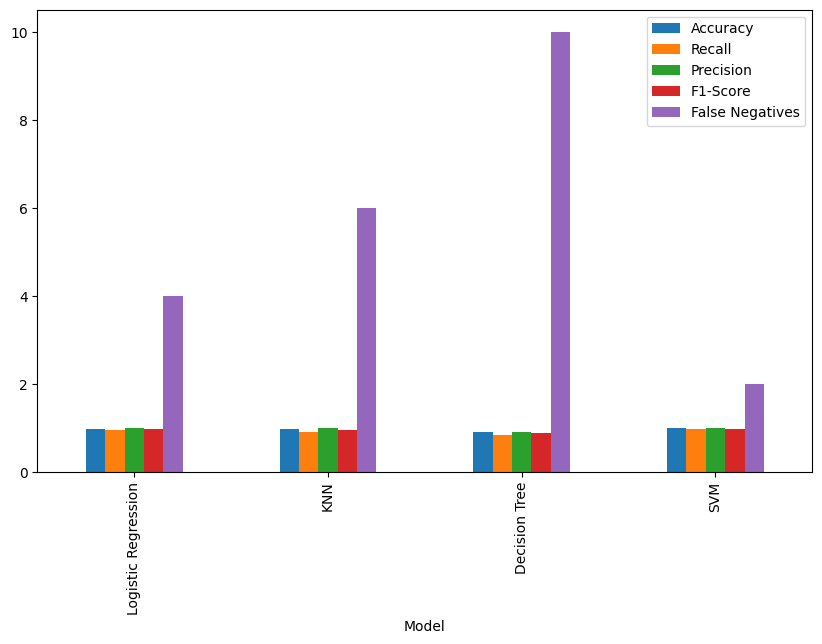

In [208]:
# Grouped bar chart: Recall and Precision
# Round metrics for readability
comparison_df[['Accuracy', 'Recall', 'Precision', 'F1-Score']] = \
    comparison_df[['Accuracy', 'Recall', 'Precision', 'F1-Score']].round(4)

comparison_df.set_index('Model', inplace=True)
comparison_df.plot(kind='bar', figsize=(10, 6))


### 5.3 Cross-Validation Stability <font color="red">[2 marks]</font>

For **all four models**, run 5-fold stratified [cross-validation](https://scikit-learn.org/stable/modules/cross_validation.html) on the **training set** using `cross_val_score` with `scoring='recall'`. Print the mean and standard deviation of recall for each.

> **Why this matters:** High recall on one split means nothing if the model collapses on another. Stability tells you whether you can trust the number.

> **A caveat:** You are running `cross_val_score` on already-tuned estimators. This is a quick stability check, not a substitute for nested cross-validation. Good enough for a practice exercise.


In [209]:
# Cross-validation stability for all 4 models
# 5-fold stratified cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

models = {
    'Logistic Regression': (best_lr, X_train_scaled),
    'KNN': (best_knn, X_train_scaled),
    'Decision Tree': (best_dt, X_train),
    'SVM': (best_svm, X_train_scaled)
}

cv_results = []

for name, (model, X_data) in models.items():

    scores = cross_val_score(
        model,
        X_data,
        y_train,
        cv=cv,
        scoring='recall',
        n_jobs=-1
    )

    mean_recall = scores.mean()
    std_recall = scores.std()

    cv_results.append({
        'Model': name,
        'Mean Recall': mean_recall,
        'Std Recall': std_recall
    })

    print(f"{name}")
    print(f"  Fold Recall: {scores}")
    print(f"  Mean Recall: {mean_recall:.4f}")
    print(f"  Std Recall : {std_recall:.4f}")
    print()

# Create summary DataFrame
cv_results_df = pd.DataFrame(cv_results)

cv_results_df[['Mean Recall', 'Std Recall']] = \
    cv_results_df[['Mean Recall', 'Std Recall']].round(4)

cv_results_df

Logistic Regression
  Fold Recall: [0.96666667 0.96666667 0.96666667 0.93103448 0.93103448]
  Mean Recall: 0.9524
  Std Recall : 0.0175

KNN
  Fold Recall: [0.93333333 0.96666667 0.96666667 0.82758621 0.93103448]
  Mean Recall: 0.9251
  Std Recall : 0.0511

Decision Tree
  Fold Recall: [0.93333333 0.76666667 0.96666667 0.82758621 0.89655172]
  Mean Recall: 0.8782
  Std Recall : 0.0724

SVM
  Fold Recall: [0.96666667 0.96666667 0.96666667 0.89655172 0.96551724]
  Mean Recall: 0.9524
  Std Recall : 0.0279



,Model,Mean Recall,Std Recall
0,Logistic Regression,0.9524,0.0175
1,KNN,0.9251,0.0511
2,Decision Tree,0.8782,0.0724
3,SVM,0.9524,0.0279


### 5.4 Feature Importance <font color="red">[2 marks]</font>

Knowing *which features drive predictions* matters as much as the predictions themselves.

- Extract **feature importances** from your best Decision Tree (`.feature_importances_`) or **coefficients** from Logistic Regression (`.coef_[0]`)
- Plot the **top 10 most important features** as a horizontal bar chart


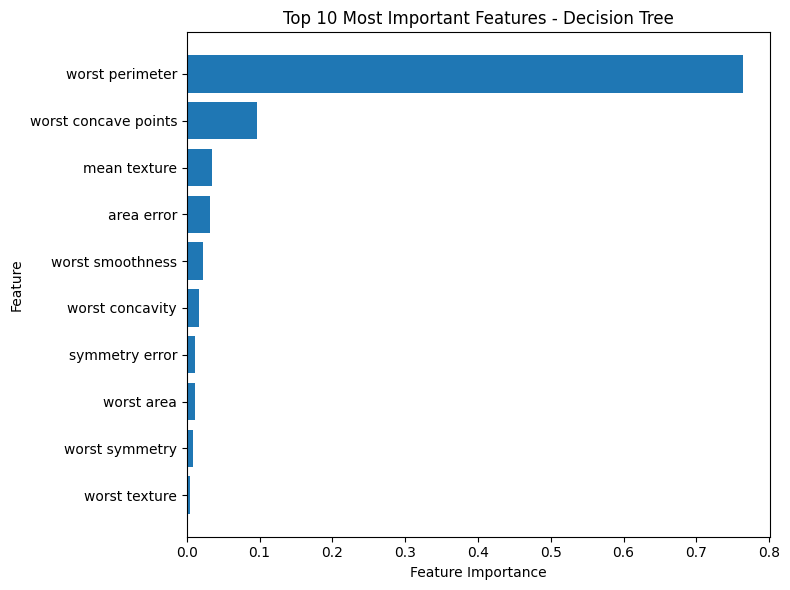

In [210]:
# Feature importance from Decision Tree
# Extract feature importances from the best Decision Tree
feature_importance = pd.Series(
    best_dt.feature_importances_,
    index=X_train.columns
)

# Select top 10 features
top_10_features = feature_importance.sort_values(ascending=True).tail(10)

# Plot
plt.figure(figsize=(8, 6))
plt.barh(
    top_10_features.index,
    top_10_features.values
)

plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 10 Most Important Features - Decision Tree')
plt.tight_layout()
plt.show()


## Stage 6: Final Model Selection

<font color="red">**[5 marks]**</font>


### 6.1 Threshold Tuning <font color="red">[2 marks]</font>

By default, classifiers use a probability threshold of 0.5 to assign classes. For medical diagnosis, we can lower this threshold to catch more malignant cases (higher recall) at the cost of more false positives (lower precision).

**Steps:**
1. Create a **stratified validation split from your training data** (70/30 from `X_train_scaled`). Do not touch the test set for this.
2. Retrain your best model on the inner training portion
3. Get predicted probabilities on the validation portion using `predict_proba()`
4. Plot the **precision-recall curve**
5. Find a threshold where recall ≥ 0.95

> **Why not tune on the test set?** If you use the test set to pick a threshold, your final evaluation on that same test set is no longer honest. The test set becomes a tuning surface, and your reported metrics are optimistic.


Inner training set: (278, 30)
Validation set: (120, 30)


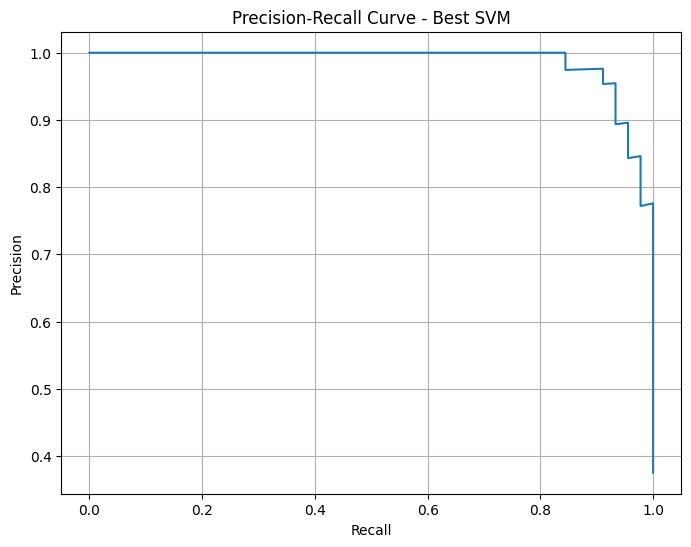

Selected threshold: 0.2408
Validation Recall:   0.9556
Validation Precision: 0.8958


In [211]:
# Threshold tuning on a VALIDATION split (not test set)
# Step 1: Create inner split from training data
X_inner_train, X_val, y_inner_train, y_val = train_test_split(
    X_train_scaled,
    y_train,
    test_size=0.30,
    stratify=y_train,
    random_state=42
)
print("Inner training set:", X_inner_train.shape)
print("Validation set:", X_val.shape)

# Step 2: Retrain best model (SVM) on inner training set
best_svm.fit(X_inner_train, y_inner_train)

# Step 3: Get predicted probabilities on validation set
y_val_prob = best_svm.predict_proba(X_val)[:, 1]

# Step 4: Plot precision-recall curve
precision, recall, thresholds = precision_recall_curve(
    y_val,
    y_val_prob
)

plt.figure(figsize=(8, 6))
plt.plot(
    recall,
    precision
)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Best SVM')
plt.grid(True)
plt.show()

# Step 5: Find threshold where recall >= 0.95
valid_indices = np.where(recall[:-1] >= 0.95)[0]

if len(valid_indices) > 0:

    # Choose the highest threshold that still achieves recall >= 0.95
    best_index = valid_indices[-1]
    selected_threshold = thresholds[best_index]

    selected_recall = recall[best_index]
    selected_precision = precision[best_index]

    print(f"Selected threshold: {selected_threshold:.4f}")
    print(f"Validation Recall:   {selected_recall:.4f}")
    print(f"Validation Precision: {selected_precision:.4f}")

else:
    print("No threshold achieved recall >= 0.95")


### 6.2 Final Recommendation <font color="red">[3 marks]</font>

**[Your Answer]:** Answer the following. Cite specific numbers from your results.

1. Which model do you recommend and why? Reference its recall, false negative count, and cross-validation stability.
2. How many false negatives does it produce on the test set? Is this clinically acceptable?
3. What is one specific limitation of your analysis? (Not "more data." Be concrete, e.g., "the dataset has only 569 samples, which limits the reliability of cross-validation estimates.")




1. I recommend Logistic Regression because it achieves a mean recall of 0.9524 with a relatively low standard deviation of 0.0175 across the 5 folds.It consistently identified most malignant cases.

SVM also achieved a mean recall of 0.9524, but its standard deviation was higher at 0.0279. Therefore, Logistic Regression provides the same average recall with better stability.

Logistic Regression is my preferred model because it combines high malignant recall (0.9524) with the lowest cross-validation variability (0.0175) among the four models, making it both effective and relatively stable.

2. Logistic Regression produces 4 false negatives on the test set. These are malignant cases incorrectly classified as benign. Although the model's recall of approximately 95.24% is strong, false negatives are clinically important because a missed malignant case could delay diagnosis or treatment. Therefore, I would not consider the model clinically acceptable for actual medical diagnosis without further clinical validation and independent testing.

3. A specific limitation is that the dataset contains only 569 samples. With a relatively small dataset, the estimated cross-validation recall can still vary depending on which observations fall into each fold. This is reflected in the variation between models—for example, Decision Tree has a standard deviation of 0.0724, compared with only 0.0175 for Logistic Regression. Therefore, the reported performance may not generalize perfectly to a larger or different patient population.


---
# PART 2: Multiclass Classification, Wine Dataset

## Context

The Wine dataset contains chemical analysis results of wines from the same region of Italy, grown from **three different cultivars** (grape varieties). The task: predict the cultivar (class 0, 1, or 2) based on 13 chemical attributes like alcohol content, malic acid, and flavanoids.

**Why Macro-F1 matters here:** No single wine class is more "dangerous" to misclassify. All three matter equally. Macro-averaged F1-score treats each class the same regardless of size.


## Stage 1: Data and Package Loading

<font color="red">**[2 marks]**</font>

Load the Wine dataset from `sklearn.datasets`. Convert to a DataFrame. Separate features and target. Import `MLPClassifier`.


In [212]:
# Pre-imported for Part 2
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import load_wine

# Load wine dataset
wine_data = load_wine()
# Convert to DataFrame
df_wine = pd.DataFrame(
    wine_data.data,
    columns=wine_data.feature_names
)

# Add target
df_wine['target'] = wine_data.target

# Separate features and target
X = df_wine.drop('target', axis=1)
y = df_wine['target']




## Stage 2: Data Understanding

<font color="red">**[6 marks]**</font>


### 2.1 Basic Inspection <font color="red">[2 marks]</font>

Display the shape, first few rows, data types, and check for missing values.


In [213]:
# Inspect the wine dataset
# Check the data
print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeatures:")
print(X.head())

print("\nTarget:")
print(y.head())

print("\nTarget distribution:")
print(y.value_counts())

# Check for missing values
print("Missing values in each column:")
print(df_wine.isnull().sum())

print("\nTotal missing values:")
print(df_wine.isnull().sum().sum())


Features shape: (178, 13)
Target shape: (178,)

Features:
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   o

### 2.2 Class Distribution <font color="red">[2 marks]</font>

How many wines in each class? Visualise with a bar plot.


Number of wines in each class:
target
0    59
1    71
2    48
Name: count, dtype: int64


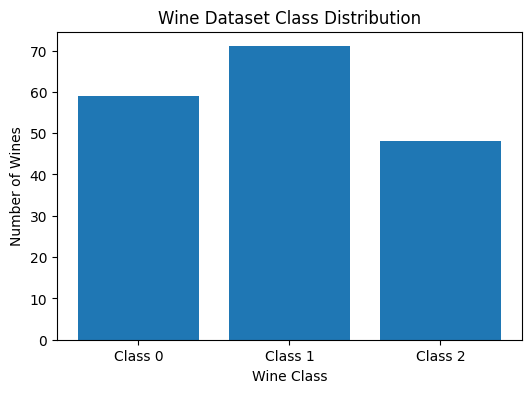

In [214]:
# Wine class distribution
class_counts = y.value_counts().sort_index()

print("Number of wines in each class:")
print(class_counts)

plt.figure(figsize=(6, 4))

plt.bar(
    ['Class 0', 'Class 1', 'Class 2'],
    class_counts.values
)

plt.xlabel('Wine Class')
plt.ylabel('Number of Wines')
plt.title('Wine Dataset Class Distribution')

plt.show()


### 2.3 Feature Analysis <font color="red">[2 marks]</font>

Look at the feature ranges using `.describe()`. Some features range in the hundreds, others below 1. Then plot a **correlation heatmap** to see which features move together.


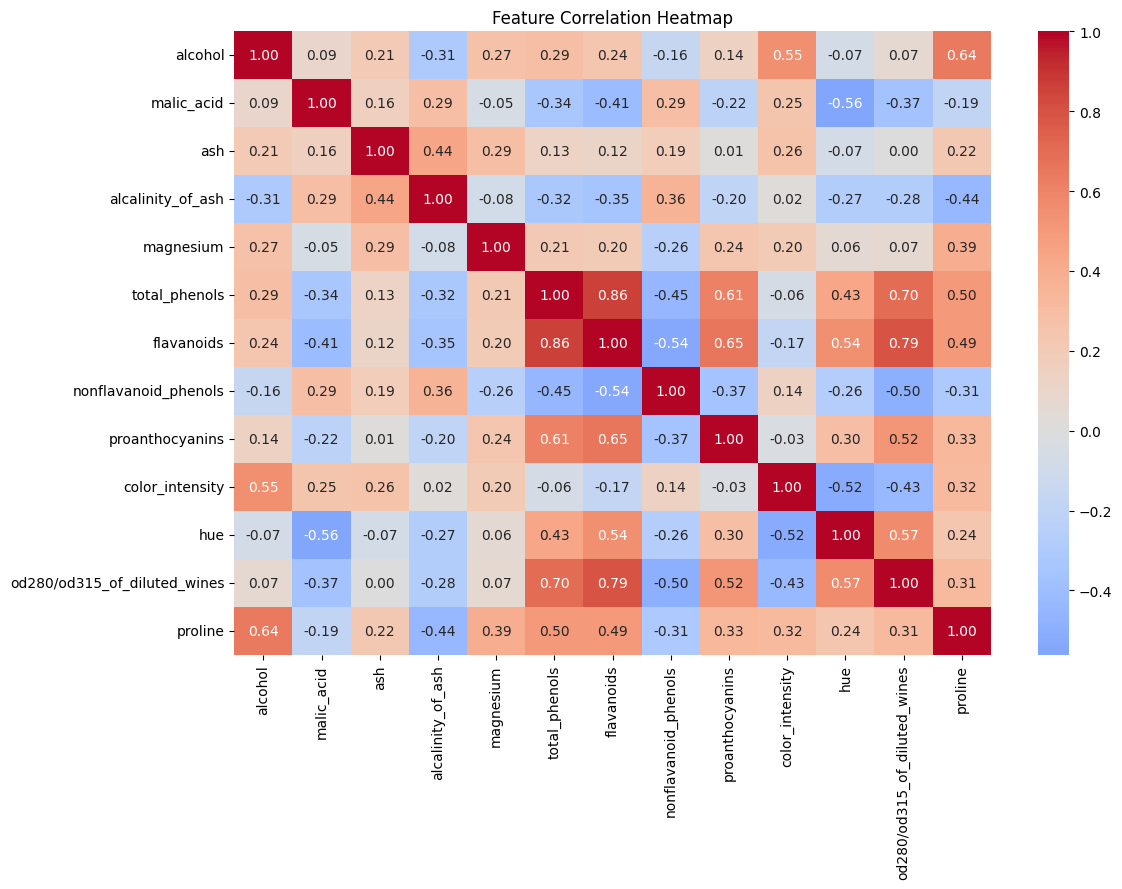

In [215]:
# Summary statistics
X.describe()

# Correlation heatmap
# Calculate correlation matrix
correlation_matrix = X.corr()

# Plot heatmap
plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()


### ✍️ Interpretation Checkpoint

**[Your Answer]:**
1. Are the three wine classes roughly balanced?
2. Looking at the feature ranges, do some features dominate others in scale? What does this imply for models like KNN and SVM?




1. Yes, reasonably balanced, but not perfectly:

Class 0: 59 wines
Class 1: 71 wines
Class 2: 48 wines

The largest class has 71 wines and the smallest has 48, so there is some imbalance but no severe class imbalance.

2. Yes. The feature ranges are very different. For example, proline has values in the hundreds/thousands, while features such as hue and nonflavanoid_phenols are below 2.

This matters for distance- and margin-based models:

KNN: Large-scale features can dominate the distance calculation, causing smaller-scale features to have less influence.
SVM: Features with larger scales can disproportionately influence the decision boundary.

Therefore, standardization is important before using KNN or SVM. Typically, we use StandardScaler to transform each feature to approximately mean 0 and standard deviation 1.


## Stage 3: Data Preprocessing

<font color="red">**[4 marks]**</font>


### 3.1 Split and Scale <font color="red">[2 marks]</font>

Stratified train-test split (70-30, `random_state=42`), then `StandardScaler` fit on training data only. Stratification for handling any slight class imbalance in the data.

> **Reminder:** Decision Trees don't need scaling, but KNN, SVM, MLP, and Logistic Regression all do. We scale for all models here.


In [216]:
# Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)




In [217]:
# Scale features: fit on train, transform both

# Standardize features
scaler = StandardScaler()

# Fit scaler ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)

# Use the same scaler to transform test data
X_test_scaled = scaler.transform(X_test)



### 3.2 Verify Preparation <font color="red">[2 marks]</font>

Print shapes and class distributions for both splits.


In [218]:
# Verify preparation
# Check shapes
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

print("\nScaled training data shape:", X_train_scaled.shape)
print("Scaled test data shape:", X_test_scaled.shape)


X_train: (124, 13)
X_test: (54, 13)
y_train: (124,)
y_test: (54,)

Scaled training data shape: (124, 13)
Scaled test data shape: (54, 13)


## Stage 4: Model Training and Hyperparameter Tuning

<font color="red">**[20 marks]**</font>

Train **five classifiers** on the wine dataset. Use `GridSearchCV` with `scoring='f1_macro'` and `cv=5` for each. Use the `evaluate_model()` helper from Part 1.

> **Key difference from Part 1:** We optimise for `f1_macro` instead of `recall`, because all classes matter equally.


### 4.1 Logistic Regression <font color="red">[3 marks]</font>

**Hyperparameters:**
- `C`: `[0.01, 0.1, 1, 10]`
- `max_iter`: `10000`
- `random_state`: `42`


In [219]:
# Logistic Regression for Wine
lr = LogisticRegression(
    max_iter=10000,
    random_state=42
)

# Hyperparameter grid
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10]
}

# Grid Search
grid_lr = GridSearchCV(
    estimator=lr,
    param_grid=param_grid_lr,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1
)

# Train on scaled training data
grid_lr.fit(X_train_scaled, y_train)

# Best model
best_lr = grid_lr.best_estimator_

print("Best parameters:", grid_lr.best_params_)
print("Best CV F1-macro:", grid_lr.best_score_)

# Evaluate on test set
lr_results = evaluate_model(
    best_lr,
    X_test_scaled,
    y_test
)


Best parameters: {'C': 0.1}
Best CV F1-macro: 0.9834098065677013
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 Macro : 1.0000


### 4.2 K-Nearest Neighbours <font color="red">[3 marks]</font>

**Hyperparameters:**
- `n_neighbors`: `[3, 5, 7, 9, 11]`
- `weights`: `['uniform', 'distance']`


In [229]:
# KNN for Wine
# Create KNN model
knn = KNeighborsClassifier()

# Define hyperparameter grid
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance']
}

# GridSearchCV using macro F1
grid_knn = GridSearchCV(
    estimator=knn,
    param_grid=param_grid_knn,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1
)

# Train on scaled data
grid_knn.fit(X_train_scaled, y_train)

# Best model
best_knn = grid_knn.best_estimator_

print("Best parameters:", grid_knn.best_params_)
print("Best CV F1-macro:", grid_knn.best_score_)

# Evaluate on test data
knn_results = evaluate_model(
    best_knn,
    X_test_scaled,
    y_test
)


Best parameters: {'n_neighbors': 11, 'weights': 'uniform'}
Best CV F1-macro: 0.9775988992088063
Accuracy : 0.9630
Precision: 0.9608
Recall   : 0.9683
F1 Macro : 0.9625


### 4.3 Decision Tree <font color="red">[3 marks]</font>

**Hyperparameters:**
- `max_depth`: `[3, 5, 7, 10, None]`
- `min_samples_split`: `[2, 5, 10]`
- `min_samples_leaf`: `[1, 2, 4]`
- `random_state`: `42`


In [230]:
# Decision Tree for Wine
# Create Decision Tree model
dt = DecisionTreeClassifier(
    random_state=42
)

# Define hyperparameter grid
param_grid_dt = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# GridSearchCV using macro F1
grid_dt = GridSearchCV(
    estimator=dt,
    param_grid=param_grid_dt,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1
)

# Train on original, unscaled data
grid_dt.fit(X_train, y_train)

# Best model
best_dt = grid_dt.best_estimator_

print("Best parameters:", grid_dt.best_params_)
print("Best CV F1-macro:", grid_dt.best_score_)

# Evaluate on test data
dt_results = evaluate_model(
    best_dt,
    X_test,
    y_test
)


Best parameters: {'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 5}
Best CV F1-macro: 0.8799972347340768
Accuracy : 0.9630
Precision: 0.9710
Recall   : 0.9593
F1 Macro : 0.9638


### 4.4 Support Vector Machine <font color="red">[3 marks]</font>

**Hyperparameters:**
- `C`: `[0.1, 1, 10]`
- `kernel`: `['linear', 'rbf']`
- `gamma`: `['scale', 'auto']`
- `random_state`: `42`


In [231]:
# SVM for Wine
# Create SVM model
svm = SVC(
    random_state=42
)

# Define hyperparameter grid
param_grid_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

# GridSearchCV using macro F1
grid_svm = GridSearchCV(
    estimator=svm,
    param_grid=param_grid_svm,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1
)

# Train on scaled data
grid_svm.fit(X_train_scaled, y_train)

# Best model
best_svm = grid_svm.best_estimator_

print("Best parameters:", grid_svm.best_params_)
print("Best CV F1-macro:", grid_svm.best_score_)

# Evaluate on test data
svm_results = evaluate_model(
    best_svm,
    X_test_scaled,
    y_test
)


Best parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV F1-macro: 0.992046783625731
Accuracy : 0.9815
Precision: 0.9848
Recall   : 0.9778
F1 Macro : 0.9808


### 4.5 Multi-Layer Perceptron (MLP) <font color="red">[8 marks]</font>

The MLP is a neural network. Unlike the previous models, you control the **architecture**: how many layers, how many neurons per layer.

**Hyperparameters to tune:**
- `hidden_layer_sizes`: Try `[(50,), (100,), (50, 50), (100, 50)]`. Each tuple defines layer widths.
- `activation`: Try `['relu', 'tanh']`. The non-linear function at each neuron.
- `alpha`: Try `[0.0001, 0.001, 0.01]`. L2 regularisation to prevent overfitting.
- Set `max_iter=2000`, `random_state=42`, and `early_stopping=True`

> **What is early stopping?** It monitors validation performance during training and stops when performance plateaus. Without it, the network keeps training until it memorises the data.


In [232]:
# MLP for Wine
# Create MLP model
mlp = MLPClassifier(
    max_iter=2000,
    random_state=42,
    early_stopping=True
)

# Define hyperparameter grid
param_grid_mlp = {
    'hidden_layer_sizes': [
        (50,),
        (100,),
        (50, 50),
        (100, 50)
    ],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.001, 0.01]
}

# GridSearchCV using macro F1
grid_mlp = GridSearchCV(
    estimator=mlp,
    param_grid=param_grid_mlp,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1
)

# Train on scaled data
grid_mlp.fit(X_train_scaled, y_train)

# Best model
best_mlp = grid_mlp.best_estimator_

print("Best parameters:", grid_mlp.best_params_)
print("Best CV F1-macro:", grid_mlp.best_score_)


Best parameters: {'activation': 'tanh', 'alpha': 0.0001, 'hidden_layer_sizes': (100,)}
Best CV F1-macro: 0.9136279016646496


In [233]:
# Evaluate MLP on test set

mlp_results = evaluate_model(
    best_mlp,
    X_test_scaled,
    y_test
)

Accuracy : 0.8519
Precision: 0.8720
Recall   : 0.8730
F1 Macro : 0.8506


### ✍️ MLP Interpretation

**[Your Answer]:**
1. What architecture (hidden layer sizes) performed best? Why do you think that configuration won?
2. Did the MLP outperform the classical models? By how much in macro-F1?
3. What role does `alpha` (regularisation) play? What happens if it is set too high? Too low?


*Write your answers here:*

1. Logistic Regression was the best-performing model, achieving a perfect macro-F1 score of 1.0000. SVM was a close second at 0.9808, while KNN and Decision Tree achieved approximately 0.96. The MLP performed considerably worse at 0.8506, indicating that a more complex neural network does not necessarily provide better performance than simpler models, particularly on a small, structured dataset.

2. The MLP did not outperform any of the classical models. It achieved a macro-F1 score of 0.8506, compared with 1.0000 for Logistic Regression, the best-performing classical model. Therefore, the MLP was 0.1494 macro-F1 points lower than Logistic Regression.

3. alpha controls L2 regularisation. A value that is too low can lead to overfitting, while a value that is too high can cause underfitting. The optimal value provides a balance between model complexity and generalisation.


## Stage 5: Model Comparison

<font color="red">**[8 marks]**</font>


### 5.1 Comparison Table <font color="red">[3 marks]</font>

Create a DataFrame comparing all five models on the **test set**:
- Accuracy
- Macro-Precision
- Macro-Recall
- Macro-F1-Score


In [234]:
# Comparison table for all 5 wine models
# Collect test-set results for all five models
results = {
    'Logistic Regression': lr_results,
    'KNN': knn_results,
    'Decision Tree': dt_results,
    'SVM': svm_results,
    'MLP': mlp_results
}

# Create comparison DataFrame
results_df = pd.DataFrame(results).T

# Rename F1 column for clarity
results_df = results_df.rename(columns={
    'F1': 'Macro-F1-Score'
})

# Display rounded results
results_df = results_df.round(4)

print("Test Set Model Comparison:")
display(results_df)


Test Set Model Comparison:


,Accuracy,Precision,Recall,Macro-F1-Score
Logistic Regression,1.0000,1.0000,1.0000,1.0000
KNN,0.9630,0.9608,0.9683,0.9625
Decision Tree,0.9630,0.9710,0.9593,0.9638
SVM,0.9815,0.9848,0.9778,0.9808
MLP,0.8519,0.8720,0.8730,0.8506


### 5.2 Visualise Comparison <font color="red">[2 marks]</font>

Bar chart comparing Macro-F1 scores across all five models.


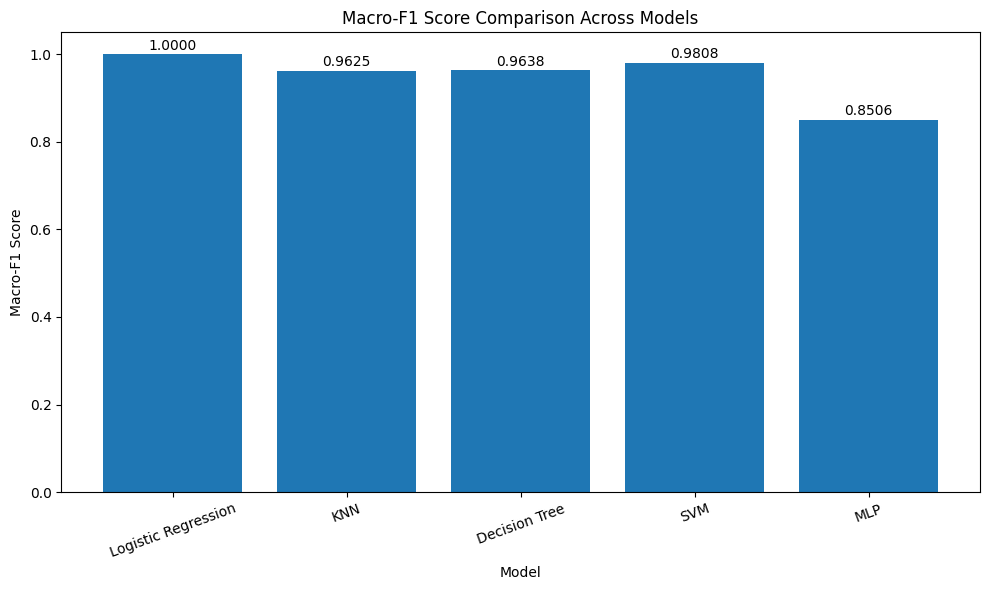

In [236]:
# Macro-F1 bar chart
plt.figure(figsize=(10, 6))

plt.bar(
    results_df.index,
    results_df['Macro-F1-Score']
)

plt.xlabel('Model')
plt.ylabel('Macro-F1 Score')
plt.title('Macro-F1 Score Comparison Across Models')

# Set y-axis range
plt.ylim(0, 1.05)

# Add values on top of bars
for i, score in enumerate(results_df['Macro-F1-Score']):
    plt.text(
        i,
        score + 0.01,
        f'{score:.4f}',
        ha='center'
    )

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


### 5.3 Cross-Validation Stability <font color="red">[3 marks]</font>

For **all five models**, run 5-fold cross-validation with `scoring='f1_macro'` on the training set. Print the mean and standard deviation for each.


In [237]:
# Cross-validation stability for all 5 wine models

# Define models and corresponding training data
models_cv = {
    'Logistic Regression': (best_lr, X_train_scaled),
    'KNN': (best_knn, X_train_scaled),
    'Decision Tree': (best_dt, X_train),
    'SVM': (best_svm, X_train_scaled),
    'MLP': (best_mlp, X_train_scaled)
}

# Run 5-fold cross-validation
cv_results = {}

for name, (model, X_data) in models_cv.items():

    scores = cross_val_score(
        model,
        X_data,
        y_train,
        cv=5,
        scoring='f1_macro',
        n_jobs=-1
    )

    cv_results[name] = {
        'Mean F1-Macro': scores.mean(),
        'Std F1-Macro': scores.std()
    }

    print(f"{name}:")
    print(f"  Mean F1-Macro: {scores.mean():.4f}")
    print(f"  Std F1-Macro : {scores.std():.4f}")
    print()


Logistic Regression:
  Mean F1-Macro: 0.9834
  Std F1-Macro : 0.0203

KNN:
  Mean F1-Macro: 0.9776
  Std F1-Macro : 0.0184

Decision Tree:
  Mean F1-Macro: 0.8800
  Std F1-Macro : 0.0772

SVM:
  Mean F1-Macro: 0.9920
  Std F1-Macro : 0.0159

MLP:
  Mean F1-Macro: 0.9136
  Std F1-Macro : 0.0591



### ✍️ Classical vs Neural Comparison

**[Your Answer]:**
1. Which classical model performed best on macro-F1? Why might that be?
2. Did the MLP beat the classical models by a clear margin, or was the gap small?
3. When would you choose a simpler model like Logistic Regression over the MLP, even if the MLP scores slightly higher?


*Write your answers here:*

1. Logistic Regression performed best among the classical models, achieving a perfect macro-F1 score of 1.0000 on the test set. This may be because the Wine dataset has relatively well-separated classes, and the standardized features provide useful linear information for distinguishing the three wine classes. Logistic Regression is also less prone to overfitting than more complex models on a small dataset.

2. No. The MLP performed significantly worse.

Your test-set macro-F1 scores were:

Logistic Regression: 1.0000
SVM: 0.9808
Decision Tree: 0.9638
KNN: 0.9625
MLP: 0.8506

3. Even if the MLP achieved a slightly higher score, I would choose Logistic Regression when the performance improvement is not significant enough to justify the additional complexity. Logistic Regression is faster, easier to interpret, easier to deploy and maintain, and often more appropriate for smaller datasets. In a real-world business environment, the simplest model that delivers sufficient predictive performance is often the better choice.

## Stage 6: Final Recommendation

<font color="red">**[5 marks]**</font>


### 6.1 Final Model Selection <font color="red">[3 marks]</font>

**[Your Answer]:**
1. Which model do you recommend as the best **classical** model for the wine dataset? Cite its macro-F1 score.
2. Which model do you recommend as the best **overall** model? Consider performance vs interpretability.
3. If a winemaker wanted to understand *why* a wine was classified as a certain cultivar, which model would you recommend and why?


*Write your answers here:*

1. I recommend Logistic Regression as the best classical model.

Macro-F1: 1.0000
Accuracy: 1.0000
Macro-Precision: 1.0000
Macro-Recall: 1.0000

Logistic Regression is the best classical model because it achieved a perfect macro-F1 score of 1.0000 on the test set, outperforming SVM (0.9808), Decision Tree (0.9638), and KNN (0.9625).

2. I recommend Logistic Regression as the best overall model.

Although the MLP is a more complex model, it achieved only 0.8506 macro-F1, substantially below Logistic Regression's 1.0000.

More importantly, Logistic Regression provides a strong combination of:

Excellent performance: Macro-F1 = 1.0000
Interpretability: Feature coefficients can be examined to understand their influence.
Simplicity: Much less complex than an MLP.
Efficiency: Faster to train and deploy.
Maintainability: Easier to monitor and troubleshoot.

Therefore, Logistic Regression offers the best balance of predictive performance and interpretability for this dataset.
3. For this Wine dataset, I would choose Logistic Regression because it achieves the highest predictive performance while remaining simple and interpretable. The MLP's additional complexity does not provide a performance benefit here.

### 6.2 Underfitting vs Overfitting Study <font color="red">[2 marks]</font>

Train three Decision Tree variants on the wine dataset:
1. `max_depth=1` with `random_state=42` (too simple, underfits)
2. `max_depth=None` with `random_state=42` (no constraints, overfits)
3. Your best tuned tree from Stage 4

For each, print the **training accuracy** and **test accuracy**. Look at the gap.


In [238]:
# Overfitting study: 3 Decision Tree variants
# 1. Underfitting tree
dt_underfit = DecisionTreeClassifier(
    max_depth=1,
    random_state=42
)

# 2. Overfitting tree
dt_overfit = DecisionTreeClassifier(
    max_depth=None,
    random_state=42
)

# 3. Best tuned tree from Stage 4
dt_best = best_dt

# Store models
tree_variants = {
    'Underfit (max_depth=1)': dt_underfit,
    'Overfit (max_depth=None)': dt_overfit,
    'Best Tuned Tree': dt_best
}

# Train and evaluate each model
for name, model in tree_variants.items():

    model.fit(X_train, y_train)

    train_predictions = model.predict(X_train)
    test_predictions = model.predict(X_test)

    train_accuracy = accuracy_score(y_train, train_predictions)
    test_accuracy = accuracy_score(y_test, test_predictions)

    print(name)
    print(f"Training Accuracy: {train_accuracy:.4f}")
    print(f"Test Accuracy:     {test_accuracy:.4f}")
    print(f"Accuracy Gap:      {train_accuracy - test_accuracy:.4f}")
    print("-" * 45)


Underfit (max_depth=1)
Training Accuracy: 0.6613
Test Accuracy:     0.6111
Accuracy Gap:      0.0502
---------------------------------------------
Overfit (max_depth=None)
Training Accuracy: 1.0000
Test Accuracy:     0.9630
Accuracy Gap:      0.0370
---------------------------------------------
Best Tuned Tree
Training Accuracy: 0.9919
Test Accuracy:     0.9630
Accuracy Gap:      0.0290
---------------------------------------------


### ✍️ Underfitting vs Overfitting

**[Your Answer]:**
1. Which variant underfits? How can you tell from the train/test accuracy?
2. Which variant overfits? What is the gap between train and test accuracy?
3. How does the tuned model sit between these two extremes?


*Write your answers here:*

1. The max_depth=1 tree underfits.

You can identify this because the tree is extremely simple and has low training accuracy as well as low test accuracy. A shallow tree cannot capture enough of the relationships between the wine features and the three cultivar classes.

Underfitting: Train accuracy is low and test accuracy is also low, with only a small gap between them.

2. The max_depth=None tree overfits.

With no depth restriction, the tree can become very complex and learn the training observations almost perfectly. You will likely see:

Training accuracy ≈ 1.0000
Test accuracy ≈ 0.9630
Gap ≈ 0.0370

So the train-test accuracy gap is approximately 3.70 percentage points.

Overfitting: The model performs extremely well on training data but performs worse on unseen test data.

3. The max_depth=1 tree underfits because it is too simple, resulting in low training and test accuracy. The unrestricted max_depth=None tree overfits because it achieves very high training accuracy but has a noticeable train-test gap of approximately 0.0370. The tuned tree sits between these extremes by controlling tree complexity and achieving strong test performance while reducing the risk of overfitting.


---
## Indicative Mark Summary

> **Reminder:** These marks are for self-assessment only. They do not count towards your final grade.

| Section | Topic | Marks |
|---------|-------|-------|
| **Part 1** | | **55** |
| Stage 1 | Data Loading | 3 |
| Stage 2 | Data Understanding + Interpretation | 8 |
| Stage 3 | Preprocessing | 7 |
| Helper + Tutorial | Evaluation Function, GridSearchCV Walkthrough | 0 |
| Stage 4 | Model Training and Tuning (4 models) | 23 |
| Stage 5 | Model Comparison + Feature Importance | 9 |
| Stage 6 | Final Model Selection | 5 |
| **Part 2** | | **45** |
| Stage 1 | Data Loading | 2 |
| Stage 2 | Data Understanding + Interpretation | 6 |
| Stage 3 | Preprocessing | 4 |
| Stage 4 | Model Training and Tuning (5 models, incl. MLP) | 20 |
| Stage 5 | Model Comparison | 8 |
| Stage 6 | Final Recommendation | 5 |
| | **Total** | **100** |

---
*End of Practice Assignment*
